In [18]:
import pandas as pd 
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt 
import os 

In [19]:
for dirname ,_, filenames in os.walk('c:/Users/Sandeep/Documents/'):
    for filename in filenames :
        if filename.endswith('csv'):
            print(os.path.join(dirname,filename))

c:/Users/Sandeep/Documents/netflix_titles.csv


In [20]:
df = pd.read_csv('c:/Users/Sandeep/Downloads/ecommerce_data_science_practice.csv')
df.head(1)

,daTransaction_ID,Timestamp,User_ID,City,Product_Category,Price_Per_Unit,Quantity,Payment_Method,Coupon_Applied,Total_Amount,Is_Repeat_Customer
0,TXN_100000,2026-04-13 19:28:00,USR_5815,Delhi,Electronics,11656.0,2,Cash on Delivery,1,23312.0,0


In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   daTransaction_ID    2500 non-null   object 
 1   Timestamp           2500 non-null   object 
 2   User_ID             2500 non-null   object 
 3   City                2460 non-null   object 
 4   Product_Category    2500 non-null   object 
 5   Price_Per_Unit      2441 non-null   float64
 6   Quantity            2500 non-null   int64  
 7   Payment_Method      2465 non-null   object 
 8   Coupon_Applied      2500 non-null   int64  
 9   Total_Amount        2441 non-null   float64
 10  Is_Repeat_Customer  2500 non-null   int64  
dtypes: float64(2), int64(3), object(6)
memory usage: 215.0+ KB


In [22]:
df.shape

(2500, 11)

In [23]:
df.isnull().sum()

daTransaction_ID       0
Timestamp              0
User_ID                0
City                  40
Product_Category       0
Price_Per_Unit        59
Quantity               0
Payment_Method        35
Coupon_Applied         0
Total_Amount          59
Is_Repeat_Customer     0
dtype: int64

In [24]:
df = df.drop_duplicates() 
price = df['Price_Per_Unit'].median()
df['Price_Per_Unit'] = df['Price_Per_Unit'].fillna(price)
df['Total_Amount'] = df['Price_Per_Unit'] * df['Quantity']
df = df.fillna({'City':'unknown', 'Payment_Method':'unknown Payment_Method'})
df.isnull().sum()

daTransaction_ID      0
Timestamp             0
User_ID               0
City                  0
Product_Category      0
Price_Per_Unit        0
Quantity              0
Payment_Method        0
Coupon_Applied        0
Total_Amount          0
Is_Repeat_Customer    0
dtype: int64

In [25]:
df = df.apply(
    lambda x : x.astype(str).str.lower().str.strip().str.replace(' ','_') 
    if x.dtype == 'object' 
    else x 
    )

df.columns = df.columns.str.lower().str.strip().str.replace(' ','_')

df.head(2)

,datransaction_id,timestamp,user_id,city,product_category,price_per_unit,quantity,payment_method,coupon_applied,total_amount,is_repeat_customer
0,txn_100000,2026-04-13_19:28:00,usr_5815,delhi,electronics,11656.0,2,cash_on_delivery,1,23312.0,0
1,txn_100001,2026-01-15_10:07:00,usr_5442,hyderabad,home_appliances,24118.0,1,debit_card,0,24118.0,1


In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   datransaction_id    2500 non-null   object 
 1   timestamp           2500 non-null   object 
 2   user_id             2500 non-null   object 
 3   city                2500 non-null   object 
 4   product_category    2500 non-null   object 
 5   price_per_unit      2500 non-null   float64
 6   quantity            2500 non-null   int64  
 7   payment_method      2500 non-null   object 
 8   coupon_applied      2500 non-null   int64  
 9   total_amount        2500 non-null   float64
 10  is_repeat_customer  2500 non-null   int64  
dtypes: float64(2), int64(3), object(6)
memory usage: 215.0+ KB


In [27]:
for i,satrt in enumerate(df['city'].unique(),start=1):
    print(i ,satrt)


1 delhi
2 hyderabad
3 bangalore
4 mumbai
5 kolkata
6 ahmedabad
7 pune
8 chennai
9 unknown


In [28]:
for city1 in df['city'].unique():
    rows, cols = df[df['city'] == city1].shape
    print(f"{city1} -> row {rows} and col {cols}")


delhi -> row 489 and col 11
hyderabad -> row 304 and col 11
bangalore -> row 358 and col 11
mumbai -> row 596 and col 11
kolkata -> row 131 and col 11
ahmedabad -> row 109 and col 11
pune -> row 269 and col 11
chennai -> row 204 and col 11
unknown -> row 40 and col 11


In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   datransaction_id    2500 non-null   object 
 1   timestamp           2500 non-null   object 
 2   user_id             2500 non-null   object 
 3   city                2500 non-null   object 
 4   product_category    2500 non-null   object 
 5   price_per_unit      2500 non-null   float64
 6   quantity            2500 non-null   int64  
 7   payment_method      2500 non-null   object 
 8   coupon_applied      2500 non-null   int64  
 9   total_amount        2500 non-null   float64
 10  is_repeat_customer  2500 non-null   int64  
dtypes: float64(2), int64(3), object(6)
memory usage: 215.0+ KB


In [30]:
df['new_total_amount'] = df['price_per_unit'] * df['quantity']
df.head()

,datransaction_id,timestamp,user_id,city,product_category,price_per_unit,quantity,payment_method,coupon_applied,total_amount,is_repeat_customer,new_total_amount
0,txn_100000,2026-04-13_19:28:00,usr_5815,delhi,electronics,11656.0,2,cash_on_delivery,1,23312.0,0,23312.0
1,txn_100001,2026-01-15_10:07:00,usr_5442,hyderabad,home_appliances,24118.0,1,debit_card,0,24118.0,1,24118.0
2,txn_100002,2026-01-21_06:57:00,usr_5142,bangalore,books,200.0,1,upi,0,200.0,0,200.0
3,txn_100003,2026-03-16_10:23:00,usr_5191,delhi,electronics,29872.0,3,upi,0,89616.0,0,89616.0
4,txn_100004,2026-04-27_03:39:00,usr_6410,delhi,clothing,1938.0,1,cash_on_delivery,1,1938.0,0,1938.0


In [31]:
df.isnull().sum() / len(df) * 100

datransaction_id      0.0
timestamp             0.0
user_id               0.0
city                  0.0
product_category      0.0
price_per_unit        0.0
quantity              0.0
payment_method        0.0
coupon_applied        0.0
total_amount          0.0
is_repeat_customer    0.0
new_total_amount      0.0
dtype: float64

C:\Users\Sandeep\AppData\Local\Temp\ipykernel_12504\2625047890.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=all_city.values,y=all_city.index, palette='husl')


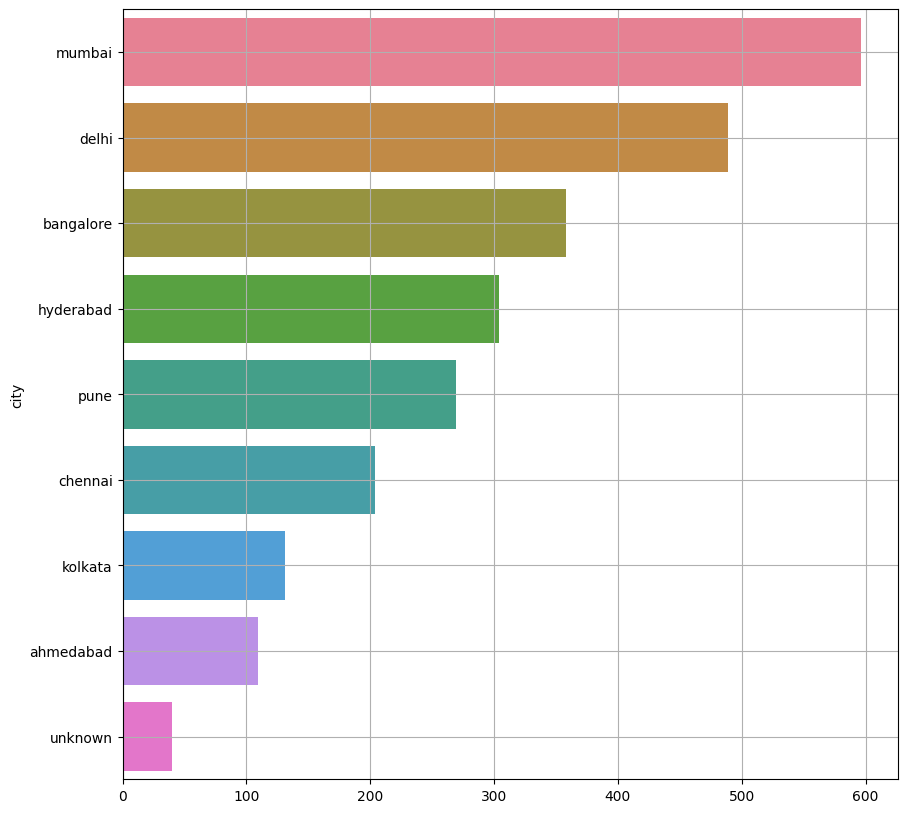

([<matplotlib.patches.Wedge at 0x1e634faaba0>,
 [Text(0.8056403156978748, 0.748961735819814, 'mumbai'),
  Text(-0.5670684646446156, 0.9425674280419404, 'delhi'),
  Text(-1.0993191532659363, -0.038696243521366705, 'bangalore'),
  Text(-0.7117615481522225, -0.8386867702378236, 'hyderabad'),
  Text(0.017968774512133124, -1.0998532280002329, 'pune'),
  Text(0.6308080834956115, -0.9011554592835765, 'chennai'),
  Text(0.9439895109613818, -0.5646979751999215, 'kolkata'),
  Text(1.0691208767232028, -0.258806010275284, 'ahmedabad'),
  Text(1.0986106449861133, -0.05526889471661297, 'unknown')])

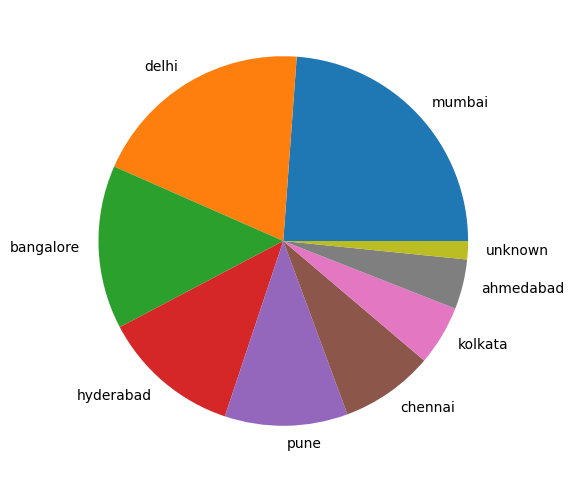

In [44]:
all_city = df.city.value_counts()

plt.figure(figsize=(10,10))
sns.barplot(x=all_city.values,y=all_city.index, palette='husl')
plt.grid(True)
plt.show()

plt.figure(figsize=(10,6))
plt.pie(all_city.values,labels=all_city.index)

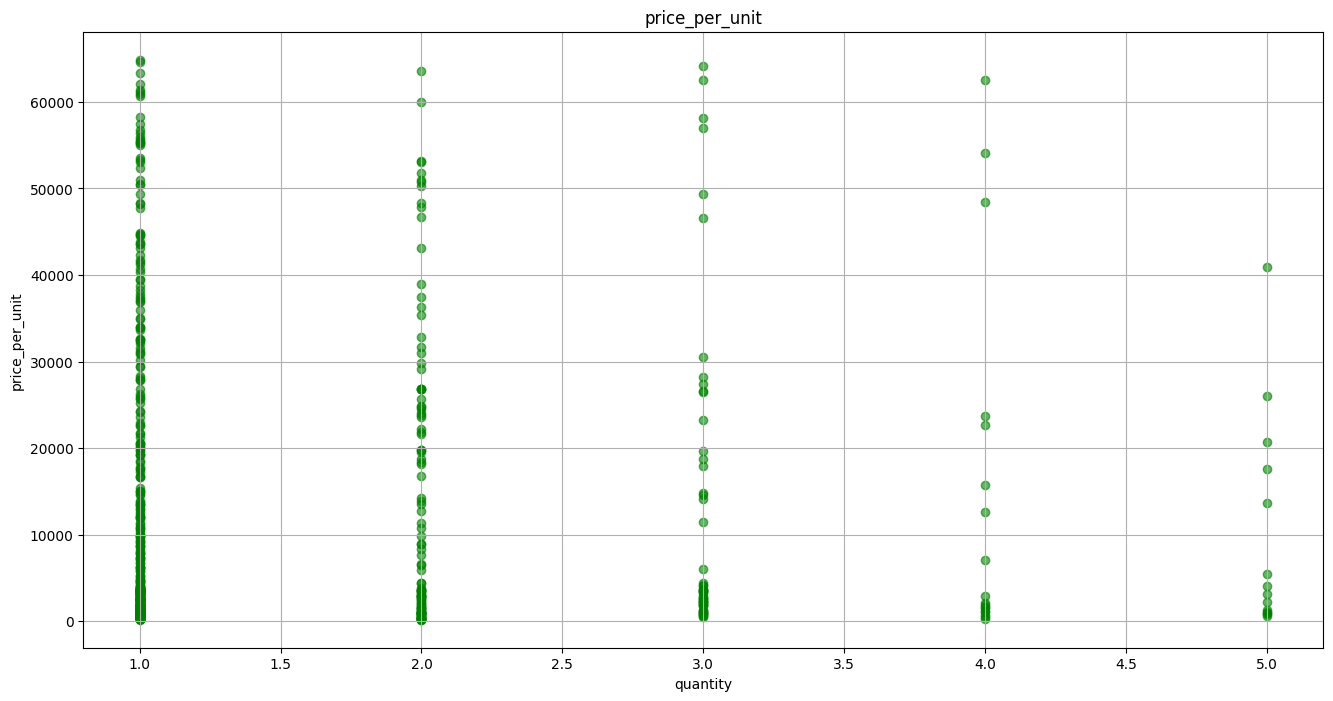

In [38]:

mumbai_cols = df[df['city'] == 'mumbai']

mumbai_new = mumbai_cols[mumbai_cols['price_per_unit'] < 100000]

plt.figure(figsize=(16,8))
plt.scatter(x=mumbai_new['quantity'],y=mumbai_new['price_per_unit'],c='g',alpha=0.6)
plt.grid(True)
plt.title('price_per_unit')
plt.xlabel('quantity')
plt.ylabel('price_per_unit')
plt.show()







In [34]:
mumbai_new.info()

<class 'pandas.core.frame.DataFrame'>
Index: 594 entries, 5 to 2492
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   datransaction_id    594 non-null    object 
 1   timestamp           594 non-null    object 
 2   user_id             594 non-null    object 
 3   city                594 non-null    object 
 4   product_category    594 non-null    object 
 5   price_per_unit      594 non-null    float64
 6   quantity            594 non-null    int64  
 7   payment_method      594 non-null    object 
 8   coupon_applied      594 non-null    int64  
 9   total_amount        594 non-null    float64
 10  is_repeat_customer  594 non-null    int64  
 11  new_total_amount    594 non-null    float64
dtypes: float64(3), int64(3), object(6)
memory usage: 60.3+ KB


np.float64(64869.0)